<a href="https://colab.research.google.com/github/Steph-business/Tech_Talent_Accelerator/blob/main/week5_day3_dalychallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training data shape: {x_train.shape}")
print(f"Testing data shape: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


### 2 & 3. Preprocess and Build Fully Connected (Dense) Network
We flatten the 28x28 images into a 784-dimensional vector and normalize them.

In [2]:
# Preprocessing for Dense model
x_train_dense = x_train.reshape(60000, 784).astype("float32") / 255
x_test_dense = x_test.reshape(10000, 784).astype("float32") / 255

# One-hot encode labels
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

# Build Dense Model
model_dense = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dense(10, activation='softmax')
])

model_dense.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Training Fully Connected Model...")
model_dense.fit(x_train_dense, y_train_cat, epochs=5, batch_size=128, verbose=1)

dense_loss, dense_acc = model_dense.evaluate(x_test_dense, y_test_cat, verbose=0)
print(f"Dense Model Accuracy: {dense_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Fully Connected Model...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9254 - loss: 0.2665
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9690 - loss: 0.1065
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9804 - loss: 0.0682
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9859 - loss: 0.0483
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9898 - loss: 0.0352
Dense Model Accuracy: 0.9811


### 4 & 5. Preprocess and Build Convolutional Neural Network (CNN)
CNNs expect the data to have a channel dimension (28, 28, 1).

In [3]:
# Preprocessing for CNN
x_train_cnn = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255
x_test_cnn = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255

# Build CNN Model
model_cnn = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Training CNN Model...")
model_cnn.fit(x_train_cnn, y_train_cat, epochs=5, batch_size=128, verbose=1)

cnn_loss, cnn_acc = model_cnn.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f"CNN Model Accuracy: {cnn_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN Model...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9426 - loss: 0.2003
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9831 - loss: 0.0549
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9881 - loss: 0.0387
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9907 - loss: 0.0291
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9925 - loss: 0.0238
CNN Model Accuracy: 0.9897


### 6. Compare the performance
Now we visualize the test accuracy of both models to see the difference clearly.

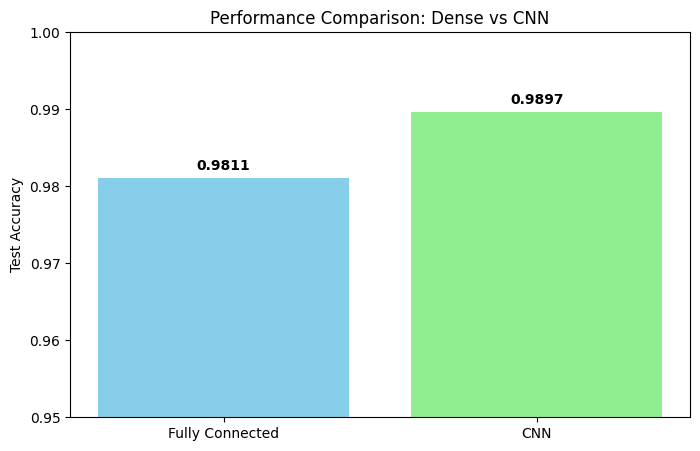

Difference in accuracy: 0.86%


In [4]:
import matplotlib.pyplot as plt

models = ['Fully Connected', 'CNN']
accuracies = [dense_acc, cnn_acc]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['skyblue', 'lightgreen'])
plt.ylim(0.95, 1.0) # Zoom in to see the difference
plt.ylabel('Test Accuracy')
plt.title('Performance Comparison: Dense vs CNN')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

print(f"Difference in accuracy: {(cnn_acc - dense_acc)*100:.2f}%")

### Conclusion
The CNN model is more effective for image classification because it preserves the spatial structure of the pixels through convolution layers, whereas the Fully Connected model loses this information by flattening the image into a single vector.